# Plotting correlation functions

## 1 Preliminaries <a id='preliminaries'></a>
### 1.1 Packages <a id='packages'></a>
[Back to content](#content)

In [14]:
# Load packages, including CAMB
%matplotlib inline
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
# Use TeX
from matplotlib import rc
rc('text', usetex=False)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})


In [15]:
from config import *                                #all constants, defined in the config.py file

from functions.useful_functions import *            #useful functions, defined in the functions/useful_functions.py file
from functions.angular_distributions import *

load_correlations(filename="correlations_NE=1_NP=1")

nTheta = 100000

In [16]:
#reading in the forecasted sample of Euclid lenses
Euclid_lenses = np.loadtxt('lenses_Euclid.txt')
zd = Euclid_lenses[:, 0]
zs = Euclid_lenses[:, 1]

# convert into comoving distances (in Mpc)
chid = background.comoving_radial_distance(zd)
chis = background.comoving_radial_distance(zs)

chimax_L = max(chis)

chimax_E = background.comoving_radial_distance(zmax_E)
chimax_P = background.comoving_radial_distance(zmax_P)

chimax = max(chimax_L,chimax_E,chimax_P) 

#place these variables in the global dictionary
add_dict(chimax, chid, chis, zd, zs)

In [17]:
get_item('L0')
print(L0)
print((6*10**(-2))**2)

0.0037676216397676335
0.0036


## 2. Correlation functions

### 2.1 Autocorrelations

#### 2.1.1 LL

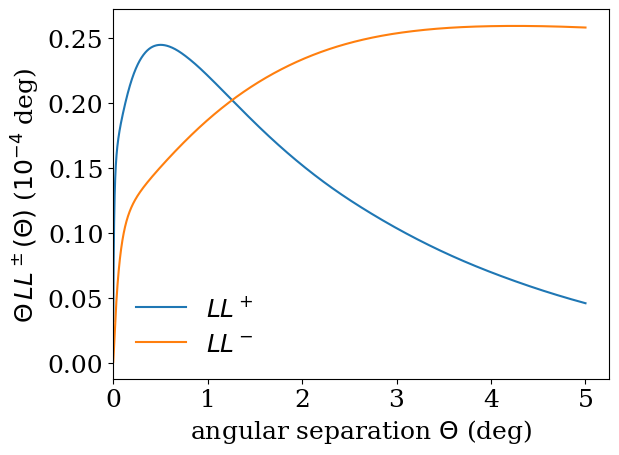

In [18]:
get_item('LL_plus', 'LL_minus')
get_item('LLp', 'LLx')

Thetamax_arcmin = 300

Thetamin = arcmintorad(Thetamin_arcmin)
Thetamax = arcmintorad(Thetamax_arcmin)

logThetamin = np.log10(Thetamin)
logThetamax = np.log10(Thetamax)
Theta = np.logspace(logThetamin, logThetamax, nTheta)

Theta_deg =  Theta * 180/np.pi

LL_plus_plot = LL_plus(Theta)
LL_minus_plot = LL_minus(Theta)

#not currently used, but available for plotting
LLp_plot = LLp(Theta)
LLx_plot = LLx(Theta)

# # Plus correlations
plt.plot(Theta_deg,
         Theta_deg * LL_plus_plot * 1e4, color='tab:blue', linestyle='-',
         label=r'$LL^+$')
# Minus correlations
plt.plot(Theta_deg,
         Theta_deg * LL_minus_plot * 1e4, color='tab:orange', linestyle='-',
         label=r'$LL^-$')

plt.xlabel(r'angular separation $\Theta$ (deg)')
plt.ylabel(r'$\Theta\,LL^\pm(\Theta)$ ($10^{-4}$ deg)')
plt.legend(frameon=False)
plt.xlim(0)
plt.show()

#### 2.1.2 EE

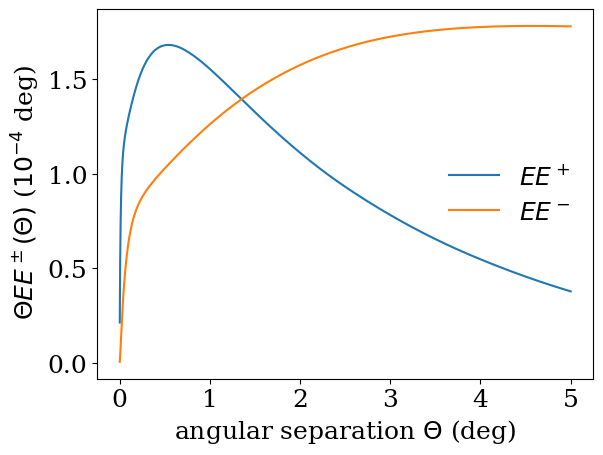

In [19]:
b1 = 0
b2 = 0

Thetamax_arcmin = 300

Thetamin = arcmintorad(Thetamin_arcmin)
Thetamax = arcmintorad(Thetamax_arcmin)

logThetamin = np.log10(Thetamin)
logThetamax = np.log10(Thetamax)
Theta = np.logspace(logThetamin, logThetamax, nTheta)

Theta_deg =  Theta * 180/np.pi
get_item('EE_plus', 'EE_minus')

EE_plus_plot = EE_plus[b1][b2](Theta)*36
EE_minus_plot = EE_minus[b1][b2](Theta)*36

# Plus correlations
plt.plot(Theta_deg,
         Theta_deg * EE_plus_plot * 1e4, color='tab:blue', linestyle='-',
         label=r'$EE^+$')
# Minus correlations
plt.plot(Theta_deg,
         Theta_deg * EE_minus_plot * 1e4, color='tab:orange', linestyle='-',
         label=r'$EE^-$')

plt.xlabel(r'angular separation $\Theta$ (deg)')
plt.ylabel(r'$\, \Theta EE^\pm(\Theta)$ ($10^{-4}$ deg)')
plt.legend(frameon=False)
plt.show()

#### 2.1.3 PP

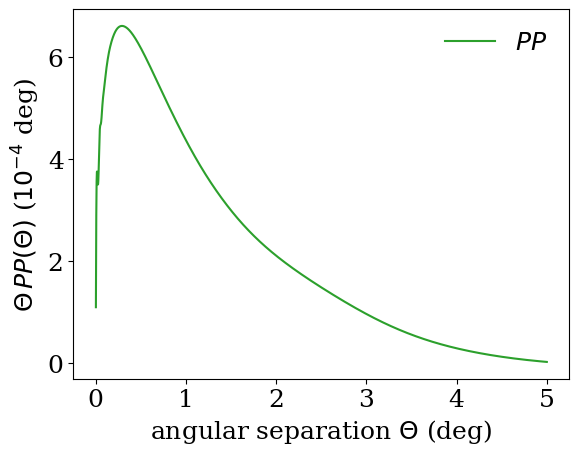

In [20]:
b1 = 0
b2 = 0

get_item('PP')


Thetamax_arcmin = 300

Thetamin = arcmintorad(Thetamin_arcmin)
Thetamax = arcmintorad(Thetamax_arcmin)

logThetamin = np.log10(Thetamin)
logThetamax = np.log10(Thetamax)
Theta = np.logspace(logThetamin, logThetamax, nTheta)

Theta_deg =  Theta * 180/np.pi

PP_plot = PP[b1][b2](Theta)

# correlations
plt.plot(Theta_deg,
         Theta_deg * PP_plot * 1e4, color='tab:green', linestyle='-',
         label=r'$PP$')

plt.xlabel(r'angular separation $\Theta$ (deg)')
plt.ylabel(r'$\Theta \, PP(\Theta)$ ($10^{-4}$ deg)')
plt.legend(frameon=False)
plt.show()

#### 2.2.1 LE

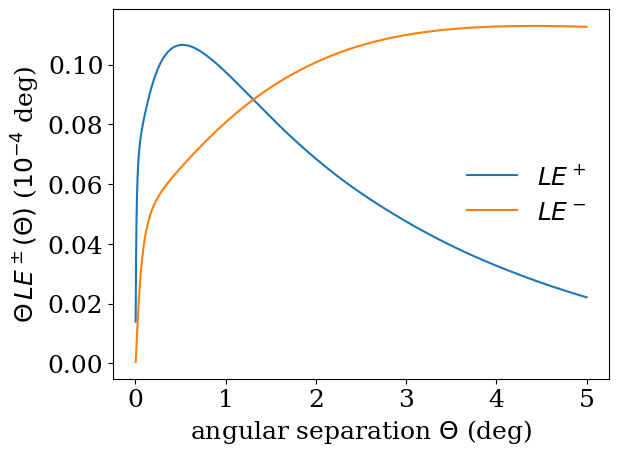

In [21]:
b1 = 0
get_item('LE_plus', 'LE_minus')

LE_plus_plot = LE_plus[b1](Theta)
LE_minus_plot = LE_minus[b1](Theta)

# Plus correlations
plt.plot(Theta_deg,
         Theta_deg * LE_plus_plot * 1e4, color='tab:blue', linestyle='-',
         label=r'$LE^+$')
# Minus correlations
plt.plot(Theta_deg,
         Theta_deg * LE_minus_plot * 1e4, color='tab:orange', linestyle='-',
         label=r'$LE^-$')

plt.xlabel(r'angular separation $\Theta$ (deg)')
plt.ylabel(r'$\Theta \, LE^\pm(\Theta)$ ($10^{-4}$ deg)')
plt.legend(frameon=False)
plt.show()

#### 2.2.2 LP

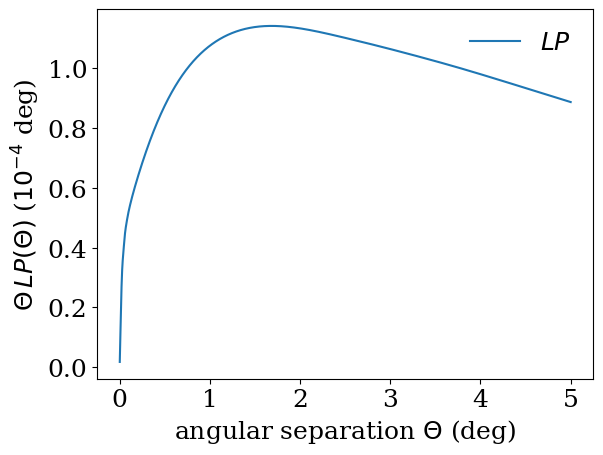

In [22]:
b1 = 0

get_item('LP')

LP_plot = LP[b1](Theta)

# correlations
plt.plot(Theta_deg,
         Theta_deg * LP_plot * 1e4, color='tab:blue', linestyle='-',
         label=r'$LP$')
plt.xlabel(r'angular separation $\Theta$ (deg)')
plt.ylabel(r'$\Theta \, LP(\Theta)$ ($10^{-4}$ deg)')
plt.legend(frameon=False)
plt.show()

#### 2.2.3 EP

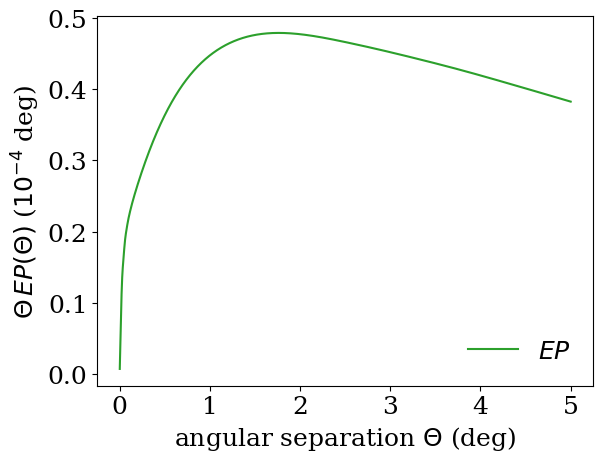

In [10]:
b1 = 0
b2 = 0

get_item('EP')

EP_plot = EP[b1][b2](Theta)

# correlations
plt.plot(Theta_deg,
         Theta_deg * EP_plot * 1e4, color='tab:green', linestyle='-',
         label=r'$EP$')
plt.xlabel(r'angular separation $\Theta$ (deg)')
plt.ylabel(r'$\Theta \, EP(\Theta)$ ($10^{-4}$ deg)')
plt.legend(frameon=False)
plt.show()

## 3. Plotting integrated correlation functions (testing optimised binscheme)

Text(0.5, 0, 'theta (deg)')

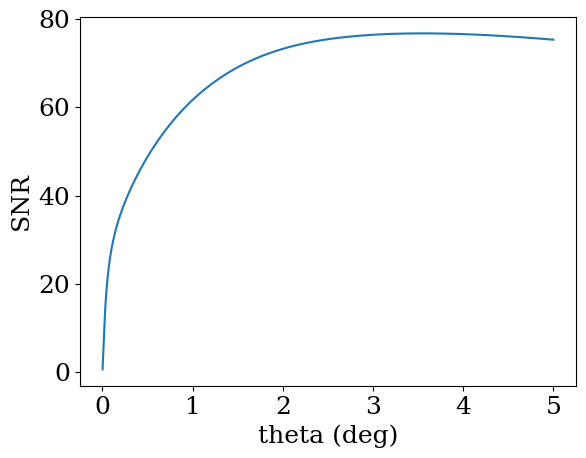

In [11]:
def integral_bins(correlation_function, Theta_start, Theta_end):

    integrand = lambda x: x*correlation_function(x)
    
    integral, err = quad(integrand, Theta_start, Theta_end)

    return integral

def SNR(integrand, theta):
    
    Omega = np.pi * theta **2 

    integral = integral_bins(integrand, 0, theta)

    return integral/np.sqrt(Omega)

Thetamax_arcmin = 300

Thetamin = arcmintorad(Thetamin_arcmin)
Thetamax = arcmintorad(Thetamax_arcmin)

logThetamin = np.log10(Thetamin)
logThetamax = np.log10(Thetamax)
Theta = np.logspace(logThetamin, logThetamax, 200)

Theta_deg = Theta * 180/np.pi

snr = []

for theta_val in Theta:
    s = SNR(LP[0], theta_val)
    snr.append(s*np.sqrt(2*(1e5)*NGal/( 6*(0.05)**2 * sky_coverage * (np.pi/180)**2 )))

plt.plot(Theta_deg,snr)
plt.ylabel('SNR')
plt.xlabel('theta (deg)')

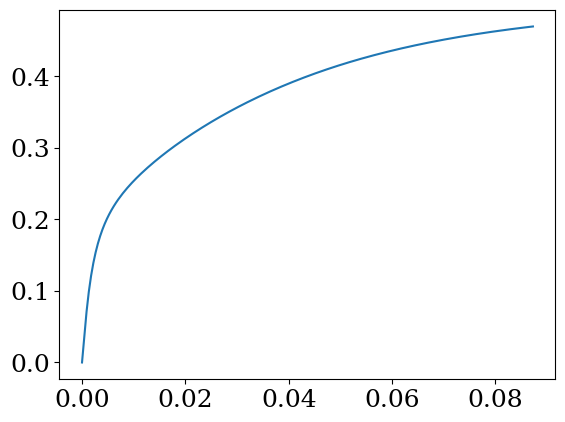

In [13]:
Nlens = 1e4
sigma_L = 0.1

get_item('LL_minus_primitive')

antiderivative = LL_minus_primitive

get_item('L0')

thetas = np.linspace(0,5,200)

thetas *= np.pi/180

correlation_type = 'LL'

def snr(theta_1, theta_2):

    numerator = antiderivative(theta_2) - antiderivative(theta_1)
    denom_sq = theta_2**2 - theta_1**2
    
    if denom_sq <= 0:
        return 0

    denominator = np.sqrt(denom_sq)
    
    if correlation_type == 'LL':
        A = 2 * np.sqrt(np.pi / Omegatot) * Nlens / (sigma_L**2 + L0)
    
    elif correlation_type == 'LE': 
        A = 2 * np.sqrt(np.pi / Omegatot) * np.sqrt( 2 * Nlens * G_B / ( (sigma_L**2 + L0) * (sigma_E**2 + E0[b]) ) )
    
    elif correlation_type == 'LP': 
        A = 2 * np.sqrt(np.pi / Omegatot) * np.sqrt( 2 * Nlens * G_B / (sigma_L**2 + L0) )
    
    return A * numerator / denominator

y = np.zeros(len(thetas))

for i in range(len(y)):
    y[i] = snr(0,thetas[i])

plt.plot(thetas,y)

In [ ]:
def optimise_bins(correlation_function, correlation_type, antiderivative, b, SNR_goal = 20, Nbin_max = 10, SNR_min = 1.5, Thetamax_distribution = Thetamax_dist):

    get_item('L0', 'E0') #we'll need these for the prefactors in the signal to noise ratios
    
    redshift_distributions = load_file('data/Nlens=1e5_sigL=0.05_Nbin_z=6_SNR_goal=8_Nbin_max=20_nsamp=1e6/redshift_distributions')

    Thetamax_distribution = arcmintorad(Thetamax_distribution)
    
    if correlation_type == 'LE':
        G_B = redshift_distributions['E'].get_ngal(b)

    elif correlation_type == 'LP':
        G_B = redshift_distributions['P'].get_ngal(b)
    
    def snr(theta_1, theta_2):

        numerator = antiderivative(theta_2) - antiderivative(theta_1)
        denom_sq = theta_2**2 - theta_1**2
        
        if denom_sq <= 0:
            return 0

        denominator = np.sqrt(denom_sq)
        
        if correlation_type == 'LL':
            A = 2 * np.sqrt(np.pi / Omegatot) * Nlens / (sigma_L**2 + L0)
        
        elif correlation_type == 'LE': 
            A = 2 * np.sqrt(np.pi / Omegatot) * np.sqrt( 2 * Nlens * G_B / ( (sigma_L**2 + L0) * (sigma_E**2 + E0[b]) ) )
        
        elif correlation_type == 'LP': 
            A = 2 * np.sqrt(np.pi / Omegatot) * np.sqrt( 2 * Nlens * G_B / (sigma_L**2 + L0) )
        
        return A * numerator / denominator

    def SNR(theta):
        return snr(0,theta)
        
    theta_optimal, SNR_max = find_maximum(SNR, 0, Thetamax_distribution)

    print(correlation_type)
    print(SNR_max)
    print('')

    if SNR_max < SNR_goal:               #if our goal SNR is unachievable, even with just 1 bin
        return [0, theta_optimal]         #return a single bin (the best we can do)

    #if the above isn't satisfied, then it means that SNR_goal < SNR_max. This means that 
    
    else: #if our goal SNR is in fact achievable, we want to iteratively determine our bins
        
        #the SNR we use is either our goal SNR or the SNR limited by the max number of bins we want
        SNR_use = max(SNR_goal, SNR_max / (np.sqrt(0.5*Nbin_max)))    

        print('SNR use = ', SNR_use)
        print('')

        binscheme = [0] #our bins start at zero    

        alpha = 0
        
        finished = False
        
        while not finished:
            
            def SNR_to_optimise(theta):
                """
                A function which goes to zero when the integrated snr between the bin limit on the left and some theta value is equal to the SNR we want to use. 
                To get to this point, we must have already passed the test that SNR_goal < SNR_max. Therefore, both SNR_goal and SNR_max / Nbin_max exist within
                the range [ binscheme[alpha], theta_optimal ], and therefore so too must their maximum, so this function will always have an x-intercept.

                Note that, for this method to work, the snr should increase monotonically up to the maximum, but it seems that this is indeed the case (check for issues!)
                """
                if theta < binscheme[alpha]:
                    print(f"Warning: theta = {theta} < {binscheme[alpha]} (alpha)")
                
                number = snr(binscheme[alpha], theta) - SNR_use
                
                return number
            
            theta_new = root_scalar(SNR_to_optimise, bracket=[binscheme[alpha], theta_optimal], method='brentq', xtol=1e-8).root

            alpha += 1
            binscheme.append(theta_new)

            #once we've found the new bin limit, we must once again define a function which returns the SNR from that bin limit to some arbitrary theta  
            def SNR(theta):
                return snr(binscheme[alpha],theta)

            thet = np.linspace(binscheme[alpha],Thetamax_distribution, 100)
            snrss = np.zeros(len(thet))
            
            for i in range(len(thet)):
                snrss[i] = SNR(thet[i]) 
                
            plt.plot(thet, snrss)

            #we then want to find what the maximum SNR beyond this point is
            theta_optimal, SNR_max = find_maximum(SNR, theta_new, Thetamax_distribution)

            #if our goal SNR is unachievable with the remaining binning 
            if SNR_max < SNR_use:     

                #if, however, the SNR is still acceptable,
                if SNR_max >= SNR_min:

                    #the optimal theta becomes the final bin limit
                    binscheme.append(theta_optimal)

                #if the SNR in the last bin would be unusable,
                else:

                    #we need a function which returns the SNR from the previous bin limit (before the most recently added one) to some arbitrary theta
                    def SNR(theta):
                        return snr(binscheme[-2],theta)

                    #this maximum might occur at the most recent bin limit, or at a higher value of theta
                    theta_optimal_new, SNR_max_new = find_maximum(SNR, binscheme[-2], Thetamax_distribution)

                    #either way, the theta we obtain in the above becomes our new final bin limit
                    binscheme[-1] = theta_optimal_new

                #either way, provided SNR_max < SNR_use, our while loop is done
                finished = True
        snrs = [snr(binscheme[alpha], binscheme[alpha+1]) for alpha in range(len(binscheme)-1)]
        
        # print(snrs)
        
        return binscheme 

## 4. Average kernel plots

In [ ]:
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
import astropy.units as u

def z(chi):
    return z_at_value(cosmo.comoving_distance, chi * u.Mpc)

# CAMB parameters
H0=67.37       #Hubble constant
ombh2=0.0223   #baryon density parameter
omch2=0.1198   #dark matter density parameter

pars = camb.CAMBparams()                              #initialise the CAMBparams object, which contains all cosmological parameters and settings
pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2)   #define the cosmological model
pars.InitPower.set_params(ns=ns)                      #set the primordial power spectrum parameters
results = camb.get_background(pars)                #compute the background cosmological evolution

### 4.1 The LOS shear

In [ ]:
#this is the same as KLOS, but with an added factor of chi
chimin=1e-5

def K_LOS(chi, chidd, chiss):
    """
    LOS weight function

    chi : an inputted value of comoving distance
    chidd : the comoving distance to the lens
    chiss : the comoving distance to the source
    """
        
    os = (chiss - chi) / chiss #the weight function for gamma_os
    od = (chidd - chi) / chidd #the weight function for gamma_od
    ds = (chi - chidd) * (chis - chi) / (chi * (chiss - chidd) ) #the weight function for gamma_ds

    #the actual weight function
    K  = (os * np.heaviside(os, 0)    #returns 0 if os is negative
          + od * np.heaviside(od, 0)
          - ds * np.heaviside(ds, 0))
    
    return K

def K_LOS_mean(chi):
    """
    Redshift-averaged LOS weight function
    
    chi : an inputted comoving distance
    """
    K = np.mean(K_LOS(chi, chid, chis))
    
    return K

def Q_LOS_mean(chi):
    """
    Redshift-averaged LOS integration kernel
    
    chi : an inputted comoving distance
    """
    redshift = background.redshift_at_comoving_radial_distance(chi)
    
    Q = 1.5 * Omega_M * (H0/(c*1e-3))**2 * (1+redshift) * K_LOS_mean(chi)
    
    return Q

# Interpolate to get a fast 1D weight function
Q_LOS_mean_vec = np.vectorize(Q_LOS_mean)
chi = np.linspace(chimin, chimax, 100)
Q = Q_LOS_mean_vec(chi)
Q_LOS_mean_intp = CubicSpline(chi, Q) 
    
nz = 100 #number of elements for discrete integral along the los
    
# Conformal distances and redshifts
chivals = np.linspace(chimin, chimax, nz) #dimension chi
zs = results.redshift_at_comoving_radial_distance(chivals) #dimension redshift
    
# Array of delta_chi, and drop first and last points where things go singular
dchivals = (chivals[2:]-chivals[:-2])/2
chivals = chivals[1:-1]
zs = zs[1:-1]

# Lensing kernel (here LOS shear)
QL = Q_LOS_mean_intp(chivals)

chivalsQL = chivals

### 4.2 The weak lensing shear

In [ ]:
Nbinz_E = 1
folder_name = f"Nlens=1e4_sigL=0.1_Nbin_z=1_SNR_goal=8_Nbin_max=20_nsamp=1e3"
redshift_distributions = load_file(f"data/{folder_name}/redshift_distributions")


def K_os(chi, chiss):
    """
    weak lensing weight function, which tells us the relative contribution of matter
    at chi to the weak lensing of a source at chis

    chi : an inputted value of comoving distance
    chiss : the comoving distance to the source
    """

    os = (chiss - chi) / chiss #the weight function for gamma_os

    #the actual weight function
    K  = os * np.heaviside(os, 0)    #returns 0 if os is negative
    
    return K

def K_os_mean(chi, b):
    """
    Redshift-averaged os integration kernel

    chi : an inputted comoving distance
    b   : the redshift bin in question
    """
    
    z_min = redshift_distributions['E'].limits[b]                                  #the minimum redshift of a source
    z_max = redshift_distributions['E'].limits[b+1]                                #the maximum redshift of a source

    #this integrand returns the probability of a source being at redshift z_source
    def integrand(z_source):
    
        p_b = redshift_distributions['E'].pb(z_source, b)                     #the probability associated with a source being at z_source (in redshift bin b)
        chi_source = background.comoving_radial_distance(z_source)            #the comoving distance to the source at z_source
        
        return p_b * K_os(chi,chi_source) 

    #we integrate our weighting function over all the source positions in the relevant bin
    K, err = integrate.quad(integrand, z_min, z_max)
    
    return K

def Q_os_mean(chi,b):
    """
    os integration kernel

    chi : an inputted value of comoving distance
    chiss : the comoving distance to the source
    """
    redshift = background.redshift_at_comoving_radial_distance(chi)
    
    Q = 1.5 * Omega_M * (H0/(c*1e-3))**2 * (1+redshift) * K_os_mean(chi,b)
    
    return Q
    
# Interpolate to get fast 1D weight functions

Q_os_mean_intp = []

for b in range(Nbinz_E):
    Q_os_mean_vec = np.vectorize(Q_os_mean)
    chi = np.linspace(chimin, chimax, 100)
    Q = Q_os_mean_vec(chi, b)
    Q_os_mean_intp.append(CubicSpline(chi, Q))

nz = 100 #number of elements for discrete integral along the los
    
# Conformal distances and redshifts
chivals = np.linspace(chimin, chimax, nz)
zs = results.redshift_at_comoving_radial_distance(chivals)

# Array of delta_chi, and drop first and last points where things go singular
dchivals = (chivals[2:]-chivals[:-2])/2
chivals = chivals[1:-1]
zs = zs[1:-1]

QE = []

for b in range(Nbinz_E):
    # Lensing kernel (here weak lensing shear)    
    QE.append(Q_os_mean_intp[b](chivals))
    
chivalsQE = chivals

### 4.3 Galaxy positions

In [ ]:
Nbinz_P = 1

def bias(z):
    return 1.1*z**2.4/(1+z)+0.9

#the "weight function" (the equivalent of W_mean in os and LOS)
def Q_d(chi, b):

    redshift = background.redshift_at_comoving_radial_distance(chi)

    H = H0 * np.sqrt(Omega_M*(1+redshift)**3+Omega_L) / (c*1e-3)
    
    return redshift_distributions['P'].pb(redshift, b) * H * bias(redshift) / chi  

print(H0 * np.sqrt(Omega_M*(1)**3+Omega_L)/ (c*1e-3) )
print(c*1e-3)

Q_d_mean_intp = []

for b in range(Nbinz_P):
    Q_d_mean_vec = np.vectorize(Q_d)
    chii = np.linspace(chimin, chimax, 100)
    Q = Q_d_mean_vec(chii, b)
    Q_d_mean_intp.append(CubicSpline(chii, Q))

# Interpolate to get fast 1D weight functions

Q_d_intp = Q_d_mean_intp  #redundant, fix this

nz = 100 #number of elements for discrete integral along the los

# Conformal distances and redshifts
chivals = np.linspace(chimin, chimax, nz)
zs = results.redshift_at_comoving_radial_distance(chivals)

# Array of delta_z, and drop first and last points where things go singular
dchivals = (chivals[2:]-chivals[:-2])/2
chivals = chivals[1:-1]
zs = zs[1:-1]

# Everything in the integrand except Weyl power spectrum

QP = []

for b in range(Nbinz_P):

    QP.append(Q_d_intp[b](chivals))

chivalsQP = chivals

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

#QL + QE on the left
axL = axes[0]
axL.plot(z(chivalsQL), QL * chivalsQL , 'k-', linewidth=3) #

for b in range(Nbinz_E):
    axL.plot(z(chivalsQE), QE[b]* chivalsQE , '--') #

axL.set_xlim(0, 2)
axL.set_ylabel(r'$\chi Q$')
axL.set_xlabel('redshift')

#QL + QP on the right
axR = axes[1]
axR.plot(z(chivalsQL), QL* chivalsQL , 'k-', linewidth=3) #

for b in range(Nbinz_P):
    axR.plot(z(chivalsQP), QP[b]*chivalsQP * 1/10 , '--') # 

axR.set_xlim(0, 2)
axR.set_xlabel('redshift')

#shared legend
handles = [] 
labels  = []

for b in range(Nbinz_E):
    handles.append(axL.lines[b+1])
    labels.append(f"bin {b}")

legend = fig.legend(
    handles, labels,
    loc='center',
    bbox_to_anchor=(0.48, 0.50),   # shift legend horizontally & vertically
    fontsize='small',
    frameon=True,
)

legend.get_frame().set_alpha(0.8)
plt.savefig('weights.png')
plt.show()